In [1]:
import warnings, time
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=UserWarning, module='statsmodels')
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set(style="whitegrid")
from pathlib import Path


from pmdarima import auto_arima
from pmdarima.arima import ndiffs, nsdiffs

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera


from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('E:\Document\PROJECT_1\data\data2324.csv')
df['Local Time'] = pd.to_datetime(df['Local Time'])
df.set_index('Local Time', inplace=True)


df_pm25 = df[['PM25']].resample('D').mean().asfreq('D')
df_pm25['PM25'] = df_pm25['PM25'].interpolate(limit_direction='both')


In [3]:
def transform(s):
    return np.log(s + 1e-6)

def inv_transform(s_t):
    return np.exp(s_t) - 1e-6

y = df_pm25['PM25'].dropna()
cutoff_test = int(len(y) * 0.8)

y_all_t = transform(y)
y_train = y_all_t.iloc[:cutoff_test].copy()
y_test  = y_all_t.iloc[cutoff_test:].copy()

print("Train:", y_train.index.min(), "->", y_train.index.max(), len(y_train))
print("Test :", y_test.index.min(), "->", y_test.index.max(), len(y_test))


Train: 2023-01-01 00:00:00 -> 2024-08-06 00:00:00 584
Test : 2024-08-07 00:00:00 -> 2024-12-31 00:00:00 147


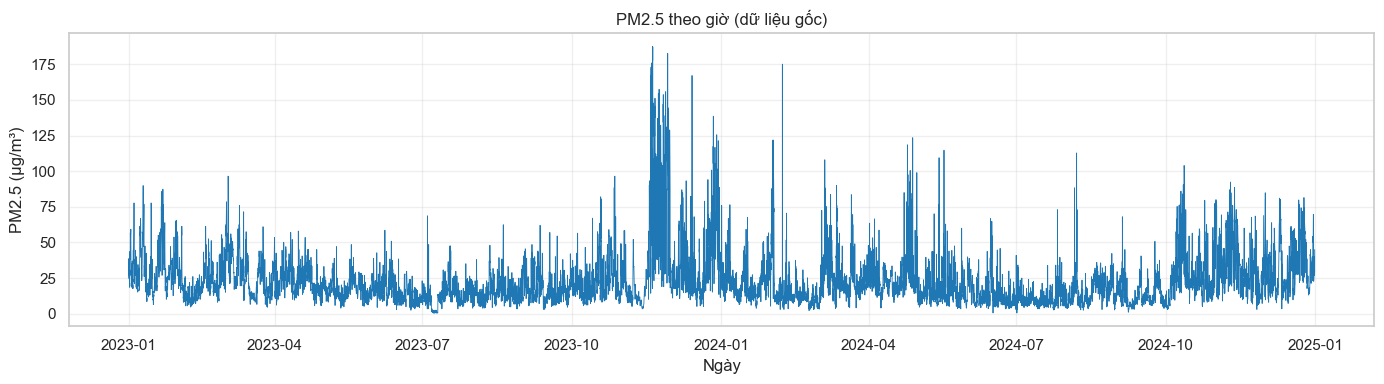

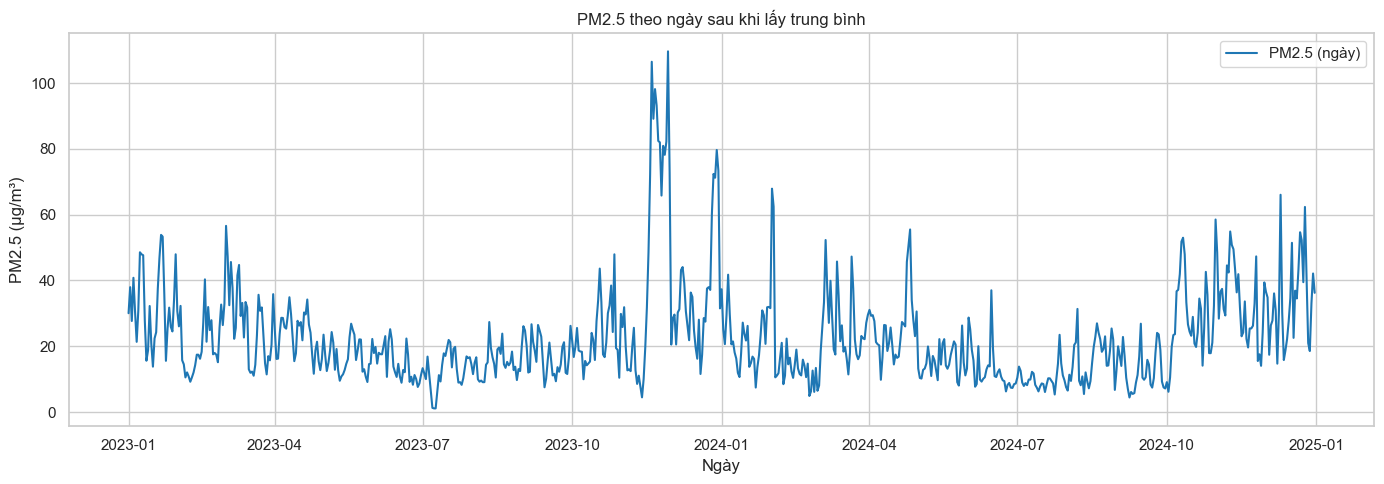

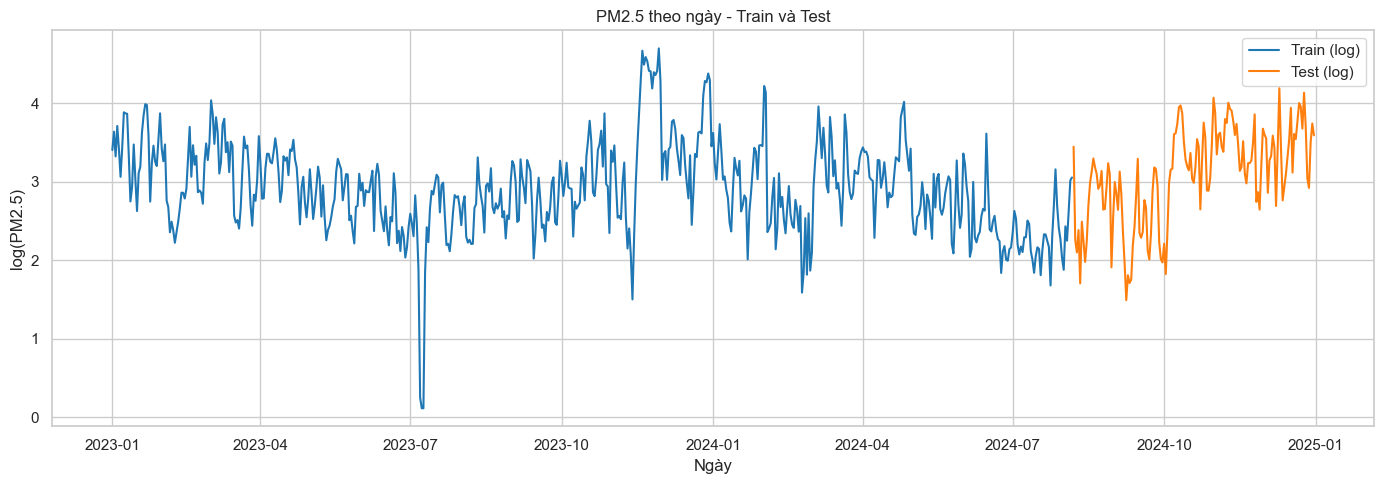

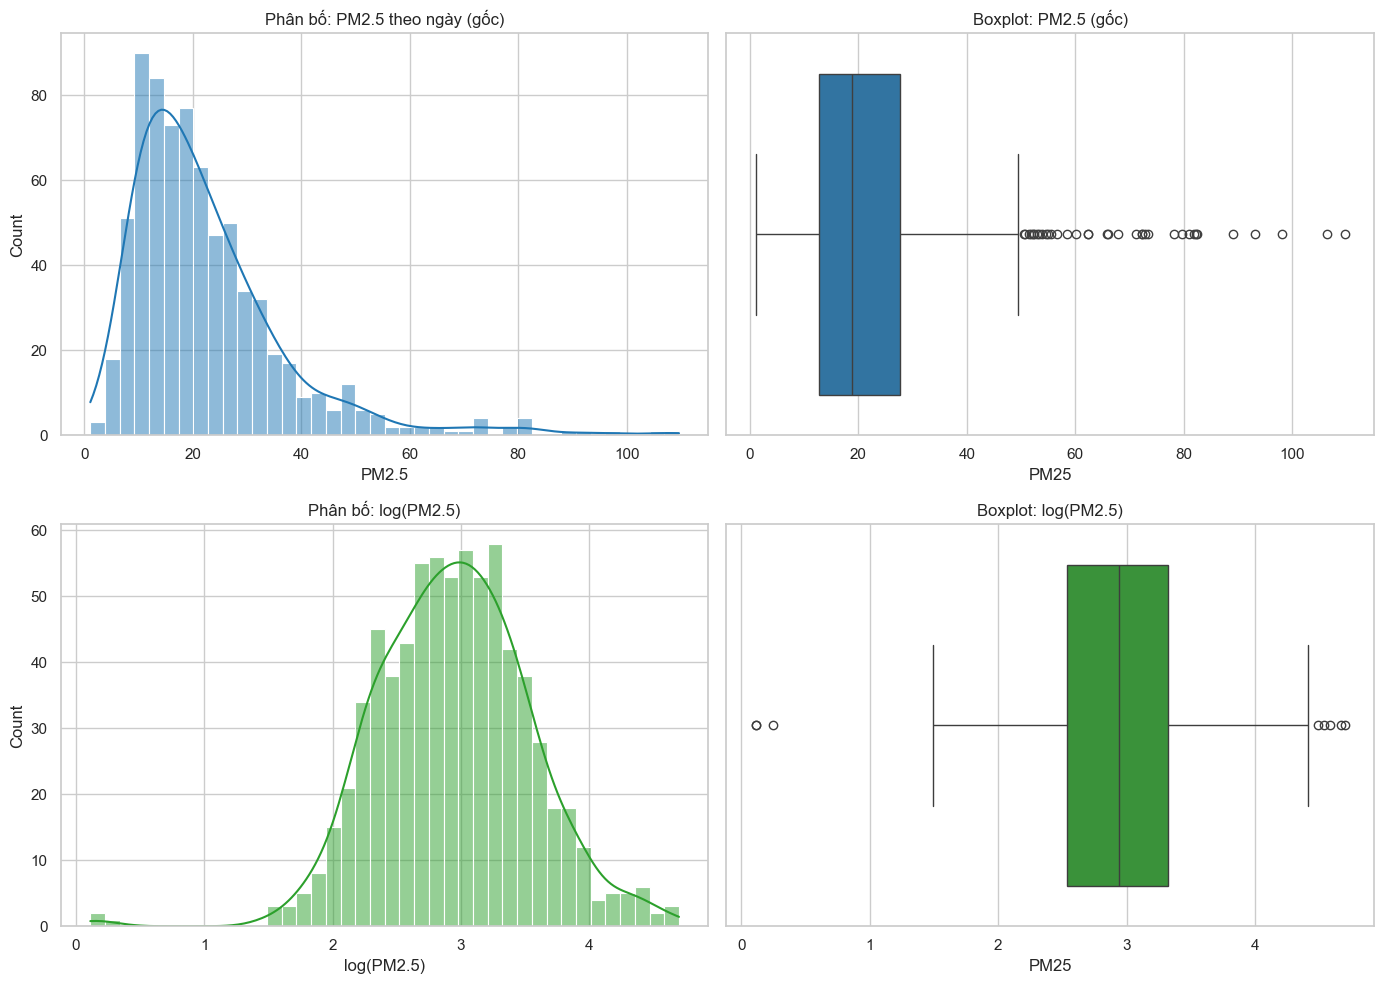

In [4]:
#  Dữ liệu gốc theo giờ
fig, ax = plt.subplots(1,1, figsize=(14,4))
ax.plot(df.index, df['PM25'], color='tab:blue', linewidth=0.6)
ax.set_title('PM2.5 theo giờ (dữ liệu gốc)')
ax.set_xlabel('Ngày')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#  PM2.5 theo ngày
plt.figure(figsize=(14,5))
plt.plot(y.index, y.values, color='tab:blue', label='PM2.5 (ngày)')

plt.title('PM2.5 theo ngày sau khi lấy trung bình')
plt.xlabel('Ngày')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.tight_layout()
plt.show()

# Dữ liệu sau khi log 
plt.figure(figsize=(14,5))
plt.plot(y_train.index, y_train.values, label='Train (log)', color='tab:blue')
plt.plot(y_test.index, y_test.values, label='Test (log)', color='tab:orange')
plt.title('PM2.5 theo ngày - Train và Test')
plt.xlabel('Ngày')
plt.ylabel('log(PM2.5)')
plt.legend()
plt.tight_layout()
plt.show()

#  Histogram & boxplot trước và sau log-transform 
y_orig = y.dropna()
y_log = y_all_t.dropna()

fig, axes = plt.subplots(2,2, figsize=(14,10))
sns.histplot(y_orig, bins=40, ax=axes[0,0], kde=True, color='tab:blue')
axes[0,0].set_title('Phân bố: PM2.5 theo ngày (gốc)')
axes[0,0].set_xlabel('PM2.5')

sns.boxplot(x=y_orig, ax=axes[0,1], color='tab:blue')
axes[0,1].set_title('Boxplot: PM2.5 (gốc)')

sns.histplot(y_log, bins=40, ax=axes[1,0], kde=True, color='tab:green')
axes[1,0].set_title('Phân bố: log(PM2.5)')
axes[1,0].set_xlabel('log(PM2.5)')

sns.boxplot(x=y_log, ax=axes[1,1], color='tab:green')
axes[1,1].set_title('Boxplot: log(PM2.5)')

plt.tight_layout()
plt.show()

Kiểm định ADF/KPSS trên y_train:
ADF statistic: -6.1794 | p-value: 0.0000
Critical Values: {'1%': -3.4416553818946145, '5%': -2.8665274458710064, '10%': -2.5694261699959413}
=> stationary (không cần sai phân)
KPSS statistic: 0.2604 | p-value: 0.1000
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
=> stationary (không reject H0)
pmdarima gợi ý: d = 0 , D = 0 (m=7)


C:\Users\hungd\AppData\Local\Temp\ipykernel_21636\3115412897.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  res = kpss(series.dropna(), regression='c', nlags='auto')


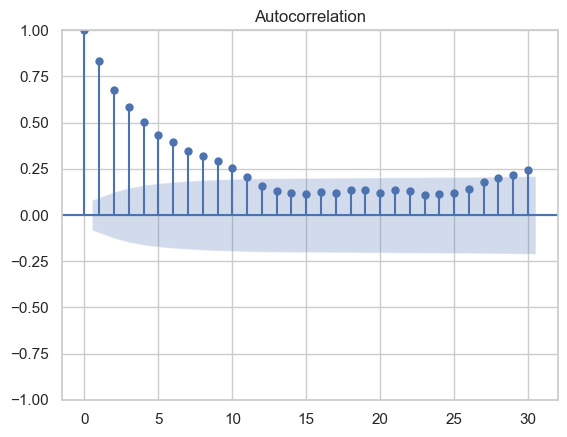

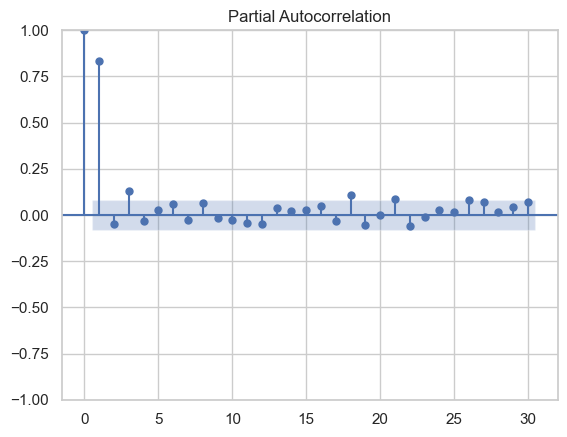

In [5]:
# Kiểm định ADF/KPSS -> tính dừng
def adf_test(series):
    res = adfuller(series.dropna(), autolag='AIC')
    print("ADF statistic: %.4f | p-value: %.4f" % (res[0], res[1]))
    print("Critical Values:", res[4])
    print("=>", "stationary (không cần sai phân)" if res[1]<0.05 else "non-stationary (cần sai phân)")

def kpss_test(series):
    res = kpss(series.dropna(), regression='c', nlags='auto')
    print("KPSS statistic: %.4f | p-value: %.4f" % (res[0], res[1]))
    print("Critical Values:", res[3])
    print("=>", "non-stationary (reject H0)" if res[1]<0.05 else "stationary (không reject H0)")

# Dùng y_train để kiểm định
y_train_goc = y.iloc[:cutoff_test]
print("Kiểm định ADF/KPSS trên y_train:")
adf_test(y_train_goc)
kpss_test(y_train_goc)

# pmdarima gợi ý d và D
d_suggest = ndiffs(y_train_goc, test='adf')
D_suggest = nsdiffs(y_train_goc, m=7, test='ch')
print("pmdarima gợi ý: d =", d_suggest, ", D =", D_suggest, "(m=7)")


plot_acf(y_train_goc.dropna(), lags=30)
plt.show()
plot_pacf(y_train_goc.dropna(), lags=30, method='ywm')
plt.show()


Trong bài báo ["Day-of-week and seasonal patterns of PM2.5 concentrations over the United States: Time-series analyses using the Prophet procedure"](https://www.sciencedirec.com/science/article/abs/pii/S1352231018305715), tác giả dùng phương pháp phân rã chuỗi thời gian (time-series decomposition) và tìm được rằng:“We observed periodically changing patterns of PM2.5 concentrations weekly and yearly.”(Chúng tôi quan sát được rằng nồng độ PM2.5 thay đổi theo chu kỳ hàng tuần và hàng năm.)

In [6]:

m0 = auto_arima(y_train, seasonal=True, m=7, trace=False,
                max_p=7, max_q=4, max_P=2, max_Q=2,
                d=0, D=None, stepwise=True, 
                error_action='ignore', suppress_warnings=True)

m1 = auto_arima(y_train, seasonal=True, m=7, trace=False,
                max_p=7, max_q=4, max_P=2, max_Q=2,
                d=1, D=None, stepwise=True, 
                error_action='ignore', suppress_warnings=True)

print("AIC d=0:", m0.aic(), m0.order, m0.seasonal_order)
print("AIC d=1:", m1.aic(), m1.order, m1.seasonal_order)
if m0.aic() < m1.aic():
    step = m0
    print("Chọn 0")
else:
    step = m1
    print("Chọn 1")

order0 = step.order
seasonal0 = step.seasonal_order
print("Kết quả:", order0, seasonal0)

AIC d=0: 438.0375081487582 (1, 0, 0) (0, 0, 0, 7)
AIC d=1: 427.77199963597934 (1, 1, 2) (1, 0, 0, 7)
Chọn 1
Kết quả: (1, 1, 2) (1, 0, 0, 7)


In [7]:
# Các dịp lễ
holiday_periods = {
    'Tết 2023': ('2023-01-20', '2023-01-26'),
    'Lễ 30/4-1/5 2023': ('2023-04-29', '2023-05-03'),
    'Lễ 2/9 2023': ('2023-08-31', '2023-09-04'),
    'Tết Dương 2024': ('2023-12-30', '2024-01-01'),
    'Tết 2024': ('2024-02-08', '2024-02-14'),
    'Lễ 30/4-1/5 2024': ('2024-04-27', '2024-05-01'),
    'Lễ 2/9 2024': ('2024-08-31', '2024-09-03'),
}

# Tạo biến ngoại sinh
pollutant_cols = ['PM10', 'NO2', 'SO2']
weather_cols = ['Pressure', 'Temperature', 'Wind Speed', 'Precipitation', 'Relative Humidity']

# Lọc chỉ lấy cột có trong df
pollutant_cols = [c for c in pollutant_cols if c in df.columns]
weather_cols = [c for c in weather_cols if c in df.columns]

# Khởi tạo DataFrame exog với index daily từ df_pm25
exog_df = pd.DataFrame(index=df_pm25.index)

# Chất ô nhiễm: lấy mean theo ngày
for c in pollutant_cols:
    exog_df[c] = df[c].resample('D').mean().reindex(exog_df.index)

# Thời tiết dùng agg 
weather_agg = {
    'Pressure': ('pressure', 'mean'),
    'Temperature': ('temperature', 'mean'),
    'Wind Speed': ('wind_speed', 'mean'),
    'Relative Humidity': ('humidity', 'median'),
    'Precipitation': [('rain', 'sum'), ('rain_hours', lambda x: (x > 0).sum())]
}

for col in weather_cols:
    if col in weather_agg:
        agg_info = weather_agg[col]
        if col == 'Precipitation':
            # Mưa
            exog_df['rain'] = df[col].resample('D').sum().reindex(exog_df.index)
            exog_df['rain_hours'] = (df[col] > 0).resample('D').sum().reindex(exog_df.index)
        else:
            new_name, agg_func = agg_info
            exog_df[new_name] = df[col].resample('D').agg(agg_func).reindex(exog_df.index)

exog_df = exog_df.asfreq('D')


# Thêm flag đánh dấu có phải cuối tuần ko

# Weekend
exog_df['IsWeekend'] = exog_df.index.dayofweek.isin([5, 6]).astype(int)

# Holiday
exog_df['IsHoliday'] = 0
for start, end in holiday_periods.values():
    exog_df.loc[(exog_df.index >= start) & (exog_df.index <= end), 'IsHoliday'] = 1

# Độ trễ(lag) cho holiday
exog_df['IsHoliday_lag1'] = exog_df['IsHoliday'].shift(1).fillna(0)
exog_df['IsHoliday_lag2'] = exog_df['IsHoliday'].shift(2).fillna(0)

# Lag-1 cho tất cả  (trừ các flag)
flag_cols = ['IsWeekend', 'IsHoliday', 'IsHoliday_lag1', 'IsHoliday_lag2']
for c in exog_df.columns:
    if c not in flag_cols:
        exog_df[f"{c}_lag1"] = exog_df[c].shift(1)

exog_df = exog_df.replace([np.inf, -np.inf], np.nan).fillna(method='bfill').fillna(method='ffill')

# TÍNH TƯƠNG QUAN VỚI PM2.5 & CHỌN BIẾN
pm25_daily = df_pm25['PM25'].asfreq('D')
df_corr = exog_df.join(pm25_daily).dropna()
corr_with_pm25 = df_corr.corr()['PM25'].drop('PM25').sort_values(ascending=False)

selected_vars = []

# Chọn biến có tương quan mạnh 
base_vars = [c for c in exog_df.columns if c not in flag_cols and not c.endswith('_lag1')]
selected_vars.extend([c for c in base_vars if abs(corr_with_pm25.get(c, 0)) >= 0.20])

#Thêm lag nếu cải thiện đáng kể (>= 0.02)
for c in selected_vars.copy():
    lagc = f"{c}_lag1"
    if lagc in corr_with_pm25.index:
        if abs(corr_with_pm25[lagc]) >= abs(corr_with_pm25[c]) + 0.02:
            selected_vars.append(lagc)


print("Tương quan với PM2.5 (daily):")
print(corr_with_pm25)

# Hiển thị biến core (biến gốc được chọn, không bao gồm lag)
core_vars = [v for v in selected_vars if v not in flag_cols and not v.endswith('_lag1')]
print(f"\nCore exog: {core_vars}")

# Hiển thị tất cả biến đã chọn
print(f"\nBiến được chọn CUỐI CÙNG cho exog:")
print(selected_vars)


Tương quan với PM2.5 (daily):
PM10                0.518761
pressure_lag1       0.458677
NO2                 0.453809
PM10_lag1           0.418006
NO2_lag1            0.417061
pressure            0.389192
SO2                 0.246950
SO2_lag1            0.189316
IsHoliday           0.028452
IsHoliday_lag1     -0.006883
IsHoliday_lag2     -0.028222
IsWeekend          -0.030108
wind_speed_lag1    -0.198255
humidity           -0.206594
wind_speed         -0.213266
rain               -0.260235
rain_lag1          -0.263683
rain_hours_lag1    -0.269411
rain_hours         -0.292883
temperature        -0.323972
humidity_lag1      -0.325087
temperature_lag1   -0.383172
Name: PM25, dtype: float64

Core exog: ['PM10', 'NO2', 'SO2', 'pressure', 'temperature', 'wind_speed', 'rain', 'rain_hours', 'humidity']

Biến được chọn CUỐI CÙNG cho exog:
['PM10', 'NO2', 'SO2', 'pressure', 'temperature', 'wind_speed', 'rain', 'rain_hours', 'humidity', 'pressure_lag1', 'temperature_lag1', 'humidity_lag1']


In [8]:
def sMAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100


def rmse(y_true, y_pred):
    y_true, y_pred = pd.Series(y_true).align(pd.Series(y_pred), join='inner')
    mask = ~(y_true.isna() | y_pred.isna())
    return float(np.sqrt(mean_squared_error(y_true[mask], y_pred[mask])))


def forecast_walkforward(y_train_tf, y_test_tf, order=(1,1,2), seasonal_order=(0,0,0,0), 
                         exog_train=None, exog_test=None):
    """ Walk-forward validation: fit lại model sau mỗi bước dự báo
    """
    import time
    t0 = time.time()
    
    # Khởi tạo history
    history_y = pd.Series(y_train_tf.astype(float).copy())
    history_x = exog_train.astype(float).copy() if exog_train is not None else None
    
    preds_tf, lo_tf, hi_tf = [], [], []
    
    for t in y_test_tf.index:
        if history_x is not None:
            history_y, history_x = history_y.align(history_x, join='inner', axis=0)       
        # Fit model
        model = SARIMAX(history_y, exog=history_x, order=order, seasonal_order=seasonal_order,
                       enforce_stationarity=False, enforce_invertibility=False)
        res = model.fit(maxiter=200, disp=False)
        
        # Dự báo 1 bước
        exog_future = exog_test.loc[[t]].astype(float) if exog_test is not None else None
        fc = res.get_forecast(steps=1, exog=exog_future)
        ci = fc.conf_int(alpha=0.05)
        
        preds_tf.append(fc.predicted_mean.iloc[0])
        lo_tf.append(ci.iloc[0, 0])
        hi_tf.append(ci.iloc[0, 1])
        
        # Cập nhật history với giá trị thực tế
        history_y = pd.concat([history_y, y_test_tf.loc[[t]]])
        if history_x is not None:
            history_x = pd.concat([history_x, exog_test.loc[[t]]])
    
    # Chuyển về Series và inverse transform
    idx = y_test_tf.index
    preds_goc = inv_transform(pd.Series(preds_tf, index=idx))
    lo_goc = inv_transform(pd.Series(lo_tf, index=idx))
    hi_goc = inv_transform(pd.Series(hi_tf, index=idx))
    
    return preds_goc, lo_goc, hi_goc, time.time() - t0

Exog cuối cùng sử dụng: ['PM10', 'NO2', 'SO2', 'pressure', 'temperature', 'wind_speed', 'rain', 'rain_hours', 'humidity', 'pressure_lag1', 'temperature_lag1', 'humidity_lag1', 'PM10_lag1']
Chạy ARIMA (1, 1, 2)
Chạy SARIMA (1, 1, 2) (1, 0, 0, 7)
Chạy SARIMAX 
Bảng so sánh
     model       mae      rmse      sMAPE      time_s
0  SARIMAX  5.242752  7.075879  22.030907  404.838281
1    ARIMA  6.872020  9.479890  28.619252   11.031890
2   SARIMA  6.904618  9.527206  28.552733   34.105452


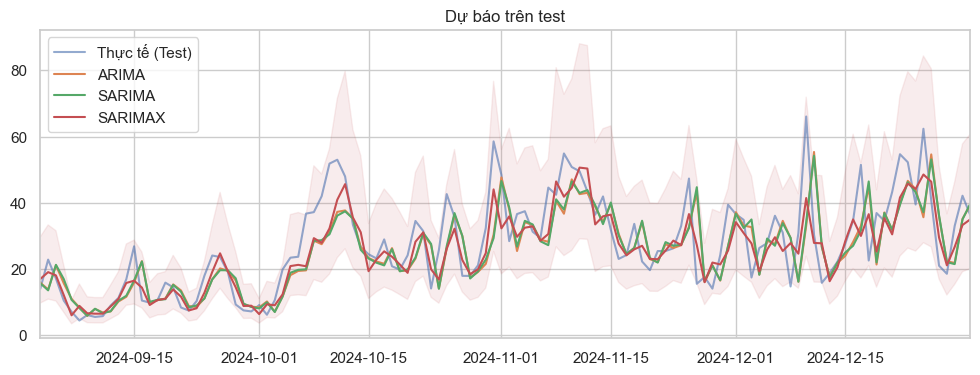

In [9]:
#chạy 3 mô hình, in MAE/RMSE/sMAPE và vẽ so sánh
exog_final = selected_vars.copy()

if 'PM10_lag1' in exog_df.columns and 'PM10_lag1' not in exog_final:
    exog_final.append('PM10_lag1')

print("Exog cuối cùng sử dụng:", exog_final)


scaler = StandardScaler()
scaler.fit(exog_df.loc[y_train.index, exog_final])

exog_scaled_all = pd.DataFrame(
    scaler.transform(exog_df[exog_final]),
    index=exog_df.index,
    columns=exog_final
)

exog_scaled_all = exog_scaled_all.replace([np.inf, -np.inf], np.nan)
exog_scaled_all = exog_scaled_all.fillna(method='bfill').fillna(method='ffill')

exog_train_sel = exog_scaled_all.loc[y_train.index] if len(exog_final) > 0 else None
exog_test_sel  = exog_scaled_all.loc[y_test.index]  if len(exog_final) > 0 else None

# ARIMA
print("Chạy ARIMA", order0)
pred_arima, lo_ar, hi_ar, t_ar = forecast_walkforward(
    y_train, y_test,
    order=order0,
    seasonal_order=(0, 0, 0, 0),
    exog_train=None,
    exog_test=None,
)

# SARIMA 
seasonal_candidate = seasonal0 if seasonal0 != (0, 0, 0, 0) else (1, 0, 1, 7)
print("Chạy SARIMA", order0, seasonal_candidate)
pred_sarima, lo_s, hi_s, t_s = forecast_walkforward(
    y_train, y_test,
    order=order0,
    seasonal_order=seasonal_candidate,
    exog_train=None,
    exog_test=None,
)

# SARIMAX walk-forward
pred_sarimax = lo_x = hi_x = None
t_x = None

if (exog_train_sel is not None) and (exog_train_sel.shape[1] > 0):
    assert exog_train_sel.isna().sum().sum() == 0
    assert exog_test_sel.isna().sum().sum() == 0

    print("Chạy SARIMAX ")
    pred_sarimax, lo_x, hi_x, t_x = forecast_walkforward(
        y_train, y_test,
        order=order0,
        seasonal_order=seasonal_candidate,
        exog_train=exog_train_sel,
        exog_test=exog_test_sel,
    )
else:
    print("Không có exog -> bỏ SARIMAX")

# 6) Tính metric trên thang gốc
y_test_goc = inv_transform(y_test)

results = []
results.append({
    'model': 'ARIMA',
    'mae':   mean_absolute_error(y_test_goc, pred_arima),
    'rmse':  rmse(y_test_goc, pred_arima),
    'sMAPE': sMAPE(y_test_goc, pred_arima),
    'time_s': t_ar
})
results.append({
    'model': 'SARIMA',
    'mae':   mean_absolute_error(y_test_goc, pred_sarima),
    'rmse':  rmse(y_test_goc, pred_sarima),
    'sMAPE': sMAPE(y_test_goc, pred_sarima),
    'time_s': t_s
})

if pred_sarimax is not None:
    results.append({
        'model': 'SARIMAX',
        'mae':   mean_absolute_error(y_test_goc, pred_sarimax),
        'rmse':  rmse(y_test_goc, pred_sarimax),
        'sMAPE': sMAPE(y_test_goc, pred_sarimax),
        'time_s': t_x
    })

res_df = pd.DataFrame(results).sort_values('mae').reset_index(drop=True)
print("Bảng so sánh")
print(res_df)

# Vẽ so sánh 
plt.figure(figsize=(12, 4))
plt.plot(y_test_goc, label='Thực tế (Test)', color='C0', alpha=0.6)
plt.plot(pred_arima,  label='ARIMA',  color='C1')
plt.plot(pred_sarima, label='SARIMA', color='C2')

if pred_sarimax is not None:
    plt.plot(pred_sarimax, label='SARIMAX', color='C3')
    if (lo_x is not None) and (hi_x is not None):
        plt.fill_between(pred_sarimax.index, lo_x, hi_x, color='C3', alpha=0.1)

plt.legend()
plt.title('Dự báo trên test')
plt.xlim(y_test_goc.index[-120], y_test_goc.index[-1])
plt.show()


In [10]:
# Chọn model tốt nhất
best = res_df.iloc[0]
print("Model tốt nhất:", best['model'], "MAE:", best['mae'])

#Fit model
if best['model'] == 'ARIMA':
    model_final = SARIMAX(y_train, order=order0, seasonal_order=(0,0,0,0),
                          enforce_stationarity=False, enforce_invertibility=False)
elif best['model'] == 'SARIMA':
    model_final = SARIMAX(y_train, order=order0, seasonal_order=seasonal_candidate,
                          enforce_stationarity=False, enforce_invertibility=False)
else:  # SARIMAX
    model_final = SARIMAX(y_train, exog=exog_train_sel, order=order0, seasonal_order=seasonal_candidate,
                          enforce_stationarity=False, enforce_invertibility=False)

res_final = model_final.fit(disp=False)
print(res_final.summary())



Model tốt nhất: SARIMAX MAE: 5.242752357926591
                                     SARIMAX Results                                      
Dep. Variable:                               PM25   No. Observations:                  584
Model:             SARIMAX(1, 1, 2)x(1, 0, [], 7)   Log Likelihood                 -89.848
Date:                            Fri, 26 Dec 2025   AIC                            215.695
Time:                                    13:39:38   BIC                            294.074
Sample:                                01-01-2023   HQIC                           246.264
                                     - 08-06-2024                                         
Covariance Type:                              opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
PM10                 0.1730      0.007     24.681      